In [1]:
import pandas as pd
import numpy as np
import regex as re
from unidecode import unidecode

# PRE-PROCESSING

In [2]:
# source = https://www.nordichq.com/guides/list-of-legal-entity-types-by-country-in-europe/
LEGAL_SUFFIXES = {
    "bv", "nv", "sa", "ag", "vof", "cv",
    "stichting", "maatschap",
    "vzw", "sl", "lp", "llp", "ohg", "ev",
    "sarl", "sca", "scs", "gmbh", "llc",
    "aps", "as", "ivs", "ks", "fmba",
    "ltd", "limited", "plc", "inc", "corp", 
    "kg", "kgaa", "oy",
    "srl", "spa", "pte", "ab", "as", "eg", "sro"
}

In [3]:
def basic_normalize(name: str) -> str:
    
    if not isinstance(name, str):
        return ""
    
    # lowercase
    name = name.lower()
    
    # unicode normalization (müller -> muller)
    name = unidecode(name)
    
    # handle initials with dots: A.B.C -> ABC, A.B.C. -> ABC
    name = re.sub(
        r'\b(?:[a-z][./])+[a-z][./]?',
        lambda m: re.sub(r'[./&]', '', m.group(0)),
        name
    )
    
    # replace punctuation with space (keep word chars, spaces)
    name = re.sub(r'[^\w\s]', ' ', name)
    
    # collapse multiple spaces
    name = re.sub(r'\s+', ' ', name).strip()
    
    return name

def remove_legal_suffixes(name: str) -> str:
    
    tokens = name.split()
    
    tokens = [
        t for t in tokens
        if t not in LEGAL_SUFFIXES
    ]
    
    return " ".join(tokens)

def remove_single_chars(name: str) -> str:

    tokens = name.split()

    long_tokens = [t for t in tokens if len(t) > 1]

    # drop only if signal remains
    if long_tokens:
        return " ".join(long_tokens)
    
    return " ".join(tokens)

In [4]:
def preprocess_company_name(name: str) -> str:
    
    name = basic_normalize(name)
    name = remove_legal_suffixes(name)
    # name = remove_single_chars(name)
    
    return name

In [ ]:
G = pd.read_csv('../G.csv', sep = '|')
STrain = pd.read_csv('../STrain.csv', sep = '|')
# STest = pd.read_csv('../STest.csv', sep = '|')
STrain = STrain.iloc[1:5000]

In [6]:
G["name_clean"] = G["name"].apply(preprocess_company_name)
STrain["name_clean"] = STrain["name"].apply(preprocess_company_name)

In [7]:
# view companies with same name_clean but with multiple company_ids
G["name_clean"].value_counts().head(10)

name_clean
siemens                      21
siemens healthcare           17
                             16
raiffeisenbank               15
abb                          15
honeywell                    13
siemens industry software    13
volksbank                    12
first state bank             11
dsv air sea                  11
Name: count, dtype: int64

In [8]:
# Identify problematic entries
G_problems = (
    (G['name_clean'].str.len() == 0) |  # Empty after cleaning
    (G['name_clean'].duplicated(keep=False))  # Any duplicate name_clean
)

# Create a clean version for matching
G_valid = G[~G_problems].copy()
G_invalid = G[G_problems].copy() 

print(f"Valid entries: {len(G_valid)}")
print(f"Invalid entries: {len(G_invalid)}")

Valid entries: 439933
Invalid entries: 10323


# BLOCKING

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3,5),
    min_df=2
)

G_tfidf = tfidf.fit_transform(G_valid["name_clean"])
G_tfidf.shape

(439933, 286760)

In [10]:
# import joblib

# # Save
# joblib.dump(tfidf, '../models/tfidf_vectorizer.joblib')
# joblib.dump(G_tfidf, '../models/G_tfidf.joblib')

In [11]:
S_tfidf = tfidf.transform(STrain["name_clean"])
S_tfidf.shape

(4999, 286760)

In [12]:
from sklearn.neighbors import NearestNeighbors

enn = NearestNeighbors(
    n_neighbors=20,
    metric='cosine',
    algorithm='brute',
    n_jobs=-1
)

enn.fit(G_tfidf)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


In [13]:
distances, indices = enn.kneighbors(S_tfidf)

In [15]:
# Build candidate pairs with similarity scores for all STrain rows
candidate_rows = []
for i in range(STrain.shape[0]):
    # Get the train_index for the current STrain row
    s_idx = STrain.iloc[i]["train_index"]
    # For each STrain row, iterate over its top-N nearest G candidates
    for j in range(indices.shape[1]):
        # Get the index of the candidate company in G
        g_row = indices[i, j]
        similarity = 1 - distances[i, j]
        # Get the candidate company_id from G
        g_id = G_valid.iloc[g_row]["company_id"]
        # Append the candidate pair and similarity score
        candidate_rows.append([s_idx, g_id, similarity])

# Create DataFrame for all candidate pairs and their similarity scores
candidates = pd.DataFrame(
    candidate_rows,
    columns=["train_index", "candidate_company_id", "tfidf_similarity"]
)

# Merge true company_id from STrain
candidates = candidates.merge(
    STrain[["train_index", "company_id"]],
    on="train_index",
    how="left"
 )

# Mark which candidate pairs are true matches
candidates["match"] = (
    candidates["candidate_company_id"] == candidates["company_id"]
).astype(int)

# Attach clean names from STrain for feature engineering
candidates = candidates.merge(
    STrain[["train_index", "name_clean"]],
    on="train_index",
    how="left"
 )
candidates = candidates.rename(columns={"name_clean": "s_name_clean"})

# Attach clean names from G for feature engineering
candidates = candidates.merge(
    G_valid[["company_id", "name_clean"]],
    left_on="candidate_company_id",
    right_on="company_id",
    how="left"
 )
candidates = candidates.rename(columns={"name_clean": "g_name_clean"})

# Clean up columns for clarity
candidates = candidates.drop(columns=["company_id_y"])
candidates = candidates.rename(columns={"company_id_x": "true_company_id"})

KeyError: 'train_index'

In [ ]:
candidates.head()

,train_index,candidate_company_id,tfidf_similarity,true_company_id,match,s_name_clean,g_name_clean
0,1,356624,0.860781,356624,1,mytyme inve stments,mytyme investments
1,1,323169,0.398002,356624,0,mytyme inve stments,investments
2,1,94412,0.398002,356624,0,mytyme inve stments,5c investments
3,1,25124,0.398002,356624,0,mytyme inve stments,j6 investments
4,1,296023,0.386995,356624,0,mytyme inve stments,st investments


In [16]:
STrain

,test_index,name,name_clean
1,1,Lone NGL FUND tSar Product Serv. LLC,lone ngl fund tsar product serv
2,2,J. S. Nich olson David Funds Trust U/A/D,j s nich olson david funds trust uad
3,3,Al Nasser Hodli. Company Limited,al nasser hodli company
4,4,"""IRCA Global SRL """,irca global
5,5,Limited Inve stent Advisors Nexus,inve stent advisors nexus
...,...,...,...
4995,4995,"EnSync, Inc.",ensync
4996,4996,ANTICA DROGH. SRL,antica drogh
4997,4997,F A FOGARTY Ltd VOLUNTARY SETTLEMENT,f a fogarty voluntary settlement
4998,4998,NORD GRUPPO PETROLI S.R.L.,nord gruppo petroli


In [22]:

import importlib
from src import candidate_generation
importlib.reload(candidate_generation)


candidates3 = candidate_generation.build_candidates(
    S_data=STrain,
    G_valid=G_valid,
    indices=indices,
    distances=distances,
    include_labels=False
)

In [ ]:
candidates2.head()

,train_index,candidate_company_id,tfidf_similarity,true_company_id,s_name_clean,g_name_clean,match
0,1,356624,0.860781,356624,mytyme inve stments,mytyme investments,1
1,1,323169,0.398002,356624,mytyme inve stments,investments,0
2,1,94412,0.398002,356624,mytyme inve stments,5c investments,0
3,1,25124,0.398002,356624,mytyme inve stments,j6 investments,0
4,1,296023,0.386995,356624,mytyme inve stments,st investments,0


In [23]:
candidates3.head()

,test_index,candidate_company_id,tfidf_similarity,s_name_clean,company_id,g_name_clean
0,1,216969,0.681577,lone ngl fund tsar product serv,216969,lone star ngl product services
1,1,253026,0.447569,lone ngl fund tsar product serv,253026,ngl
2,1,494588,0.432189,lone ngl fund tsar product serv,494588,land product
3,1,296138,0.416458,lone ngl fund tsar product serv,296138,lone star ngl marketing
4,1,560835,0.411324,lone ngl fund tsar product serv,560835,invest product a s


In [ ]:
recall = candidates[candidates["match"] == 1].shape[0] / \
         STrain[STrain["company_id"] != -1].shape[0]

print("Blocking Recall:", recall)

# ngram_range = (3,3), min_df = 2 // FAISS + SVD 512 @ k=10 --> recall 0.233
# ngram_range = (3,5), min_df = 2 // FAISS + SVD 512 @ k=10 --> recall 0.2828
# ngram_range = (3,5), min_df = 2 // cosine ENN @ k=10 --> recall 0.808
# ngram_range = (3,5), min_df = 2 // cosine ENN @ k=20 --> recall 0.8268 (diff preprocessing)

Blocking Recall: 0.8324771689497716


# 4. Feature Engineering

In [ ]:
def tokenize(name: str) -> set:
    """Tokenize a string into a set of words. Returns an empty set if input is not a string."""
    if not isinstance(name, str):
        return set()
    return set(name.split())

In [ ]:
from rapidfuzz import fuzz
from rapidfuzz.distance import JaroWinkler

def compute_features(row):
    """
    Compute a set of similarity and token-based features for a candidate pair of company names.
    Expects a row with 's_name_clean' and 'g_name_clean' columns.
    Returns a pandas Series with feature values.
    """
    # Extract cleaned names for S and G
    s = row["s_name_clean"]
    g = row["g_name_clean"]

    # Handle missing or non-string values gracefully
    if not isinstance(s, str):
        s = ""
    if not isinstance(g, str):
        g = ""

    # Tokenize both names into sets of words
    s_tokens = tokenize(s)
    g_tokens = tokenize(g)

    # Calculate token overlap (intersection and union)
    intersection = len(s_tokens & g_tokens)  # Number of shared tokens
    union = len(s_tokens | g_tokens)         # Total unique tokens across both names

    # Jaccard similarity: ratio of shared tokens to total unique tokens
    jaccard = intersection / union if union > 0 else 0

    # Length ratio: shorter name length divided by longer name length
    len_ratio = min(len(s), len(g)) / max(len(s), len(g)) if max(len(s), len(g)) > 0 else 0

    # Compute and return all features as a Series
    return pd.Series({
        # Fuzzy string similarity metrics (normalized to [0,1])
        # "lev_ratio": Levenshtein.normalized_similarity(s, g), # Normalized Levenshtein similarity
        "jaro_winkler": JaroWinkler.normalized_similarity(s, g), # Jaro-Winkler similarity
        "token_set_ratio": fuzz.token_set_ratio(s, g) / 100, # Token set ratio (compares shared words only)
        "token_sort_ratio": fuzz.token_sort_ratio(s, g) / 100, # Token sort ratio (sorts tokens alphabetically before comparing)
        "partial_ratio": fuzz.partial_ratio(s, g) / 100, # Partial ratio (looks for best matching substring)

        # Token-based features
        "jaccard": jaccard, # Jaccard similarity score

        # Length-based features
        "len_ratio": len_ratio, # Ratio of name lengths
        "len_diff": abs(len(s) - len(g)), # Absolute difference in name lengths
    })

In [ ]:
# 1min 50sec on 1 mill rows no phonetic features;
# 2min 30sec with phonetic features (jw metaphone full string); 
# 2min 45sec phonetic features (metaphone token-level features)
feature_df = candidates.apply(
    compute_features,
    axis=1
)

In [ ]:
# Create training df
train_df = pd.concat(
    [candidates, feature_df],
    axis=1
)

# 5. Train model

In [ ]:
feature_cols = [
    "tfidf_similarity",
    "jaro_winkler",
    "token_set_ratio",
    "token_sort_ratio",
    "partial_ratio",
    "jaccard",
    "len_ratio",
    "len_diff"
]

X = train_df[feature_cols]
y = train_df["match"]

In [ ]:
train_df["match"].value_counts()

match
0    943728
1     56272
Name: count, dtype: int64

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight={0:1, 1:5},   # penalize false positives
    max_iter=1000
)

model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{0: 1, 1: 5}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For 

In [ ]:
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X)[:,1]

print(roc_auc_score(y, probs))

# original setup 23.03 ROC_AUC: 0.9143
# jw + jw metaphone match feature (full strings): ROC_AUC: 0.9272
# jw only (no metaphone features): ROC_AUC: 0.9269

0.9271894712669098


### XGBOOST

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_model = XGBClassifier(
    scale_pos_weight=1,
    max_depth=8,              # Deeper trees
    learning_rate=0.05,       # Lower learning rate
    n_estimators=300,         # More trees
    min_child_weight=3,       # Regularization
    subsample=0.8,            # Row sampling
    colsample_bytree=0.8,     # Column sampling
    gamma=0.1,                # Min split loss
    reg_alpha=0.1,            # L1 regularization
    reg_lambda=1.0,           # L2 regularization
    random_state=42
)

xgb_model.fit(X, y)
xgb_probs = xgb_model.predict_proba(X)[:,1]
print(roc_auc_score(y, xgb_probs))

0.9718034325066439


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


tv_xgb_model = XGBClassifier(
    scale_pos_weight=1,
    max_depth=12,              # Deeper trees
    learning_rate=0.05,       # Lower learning rate
    n_estimators=300,         # More trees
    min_child_weight=3,       # Regularization
    subsample=0.9,            # Row sampling
    colsample_bytree=0.9,     # Column sampling
    gamma=0,                # Min split loss
    # reg_alpha=0.1,            # L1 regularization
    # reg_lambda=1.0,           # L2 regularization
    random_state=42
)

tv_xgb_model.fit(X_train, y_train)
val_probs = tv_xgb_model.predict_proba(X_val)[:,1]
print(f"Validation ROC_AUC: {roc_auc_score(y_val, val_probs)}")

Validation ROC_AUC: 0.9669814379517915


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [6, 8, 10, 12],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 500],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
}

search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=1, random_state=42),
    param_dist, n_iter=50, cv=3, scoring='roc_auc', n_jobs=-1
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
# 24.03 Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 12, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.9}

Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 12, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.9}


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and ROC area for XGBoost
fpr, tpr, _ = roc_curve(y, xgb_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
G["name_clean"] = G["name"].apply(preprocess_company_name)
STrain["name_clean"] = STrain["name"].apply(preprocess_company_name)

# 6. Threshold Optimization

In [ ]:
train_df["match_prob"] = xgb_probs

best_candidates = (
    train_df
    .sort_values("match_prob", ascending=False)
    .groupby("train_index")
    .first()
    .reset_index()
)

In [ ]:
def compute_cost(df, threshold):
    # Determine which rows are predicted as matches based on the threshold
    pred_match = df["match_prob"] >= threshold
    
    # Assign predicted company_id: if predicted as match, use candidate_company_id; else -1
    pred_id = np.where(pred_match, df["candidate_company_id"], -1)
    
    # True company_id for each row
    true_id = df["true_company_id"]
    
    # Count false positives
    fp = np.sum(
        (pred_id != -1) &
        (pred_id != true_id)
    )
    
    # Count false negatives
    fn = np.sum(
        (pred_id == -1) &
        (true_id != -1)
    )
    
    # Count true positives
    tp = np.sum(
        (pred_id != -1) &
        (pred_id == true_id)
    )

    total_cost = 5*fp + 1*fn
    
    return total_cost, fp, fn, tp

In [ ]:
# Sweep thresholds to evaluate cost, FP, FN, TP at each value
thresholds = np.linspace(0,1,200)

results = []

for t in thresholds:
    # Compute cost and error counts for each threshold
    cost, fp, fn, tp = compute_cost(best_candidates, t)
    results.append([t, cost, fp, fn, tp])

cost_df = pd.DataFrame(
    results,
    columns=["threshold","cost","fp","fn","tp"]
)

In [ ]:
best_row = cost_df.loc[cost_df["cost"].idxmin()]

t_star = best_row["threshold"]

print("Optimal threshold:", t_star)
print("Min cost:", best_row["cost"])
print("FP:", best_row["fp"])
print("FN:", best_row["fn"])
print("TP:", best_row["tp"])

Optimal threshold: 0.03015075376884422
Min cost: 58599.0
FP: 4378.0
FN: 36709.0
TP: 30136.0


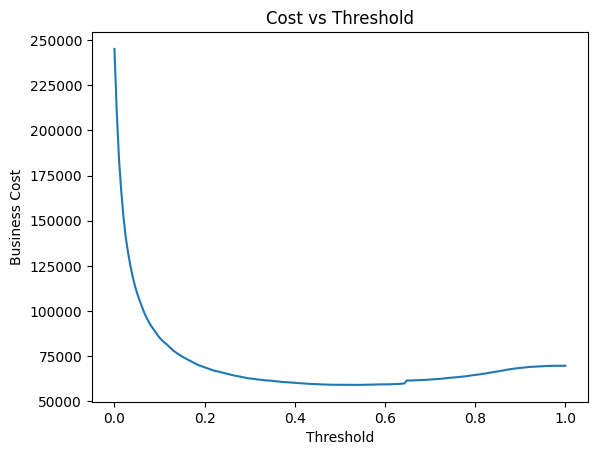

In [ ]:
plt.plot(cost_df["threshold"], cost_df["cost"])
plt.xlabel("Threshold")
plt.ylabel("Business Cost")
plt.title("Cost vs Threshold")
plt.show()

# 7. Result metrics on STrain

In [ ]:
# Get FP and FN from cost_df at optimal threshold
fp = int(best_row["fp"])
fn = int(best_row["fn"])
tp = int(best_row["tp"])

# Calculate metrics
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print("Min cost:", best_row["cost"])
print(f"Optimal Threshold: {t_star:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Min cost: 58599.0
Optimal Threshold: 0.0302
Precision: 0.8732
Recall: 0.4508
F1 Score: 0.5946
